In [ ]:
import tensorflow as tf
import visualkeras
from PIL import ImageFont

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name="Input"),
    tf.keras.layers.Dense(128, activation="relu", name="Hidden_1"),
    tf.keras.layers.Dense(64, activation="relu", name="Hidden_2"),
    tf.keras.layers.Dense(32, activation="relu", name="Hidden_3"),
    tf.keras.layers.Dense(10, activation="softmax", name="Output")
])

# Optional font
font = ImageFont.load_default()

# Generate neural network diagram
visualkeras.layered_view(
    model,
    legend=True,
    font=font,
    spacing=30,
    scale_xy=15,
    scale_z=2,
    max_z=100
).show()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'Dense' object has no attribute 'output_shape'

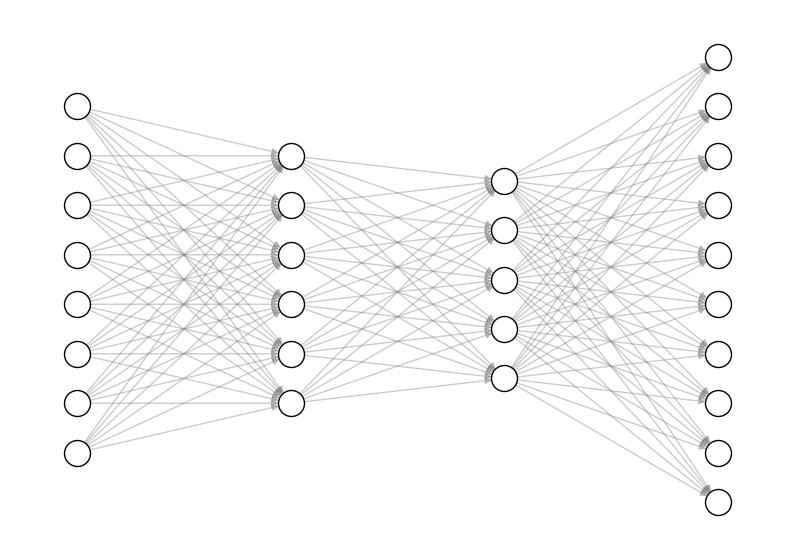

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

layers = [8, 6, 5, 10]

G = nx.DiGraph()
pos = {}

x = 0
for i, layer in enumerate(layers):
    y_offset = -(layer - 1) / 2
    for j in range(layer):
        node = f"L{i}_{j}"
        G.add_node(node)
        pos[node] = (x, y_offset + j)

        if i > 0:
            for k in range(layers[i - 1]):
                G.add_edge(f"L{i-1}_{k}", node)

    x += 2

plt.figure(figsize=(10,7))
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="white",
    edgecolors="black",
    node_size=350
)

plt.axis("off")
plt.show()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


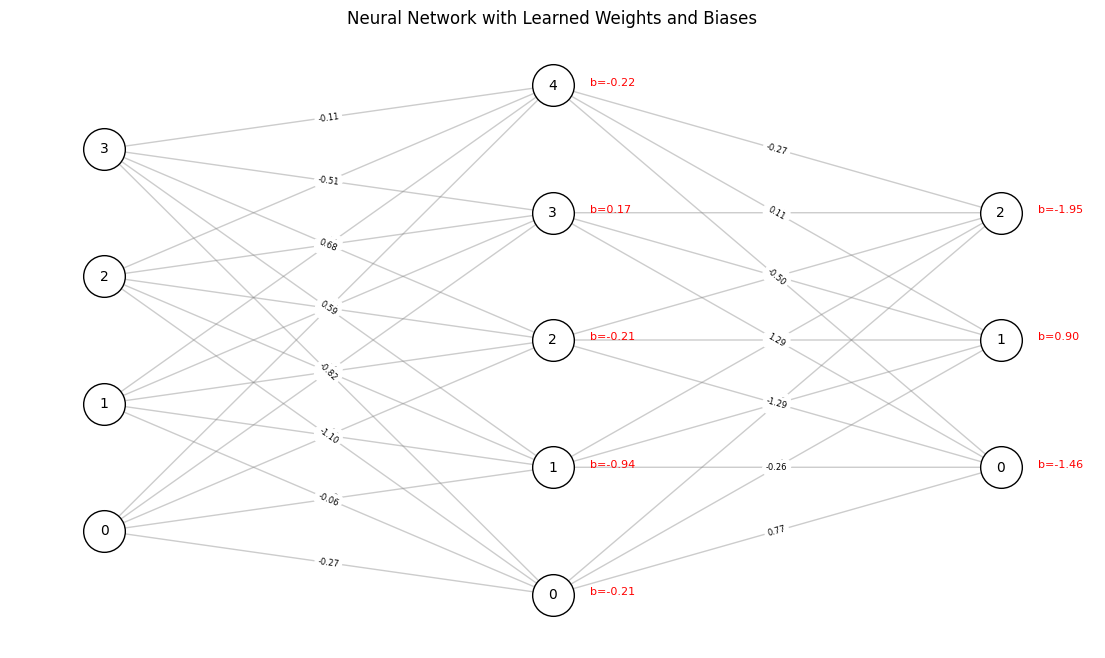

Accuracy: 1.0


In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Neural Network
# -----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Extract Weights and Biases
# -----------------------------
weights = model.coefs_
biases = model.intercepts_

layers = [4, 5, 3]      # Input, Hidden, Output

G = nx.DiGraph()
pos = {}

x_gap = 3

# Create nodes
for i, layer_size in enumerate(layers):

    y_offset = -(layer_size-1)/2

    for j in range(layer_size):

        node = f"L{i}_{j}"

        G.add_node(node)

        pos[node] = (i*x_gap, y_offset+j)

# Create edges with weights
edge_labels = {}

for l in range(len(weights)):

    W = weights[l]

    for i in range(W.shape[0]):
        for j in range(W.shape[1]):

            n1 = f"L{l}_{i}"
            n2 = f"L{l+1}_{j}"

            G.add_edge(n1, n2)

            edge_labels[(n1,n2)] = f"{W[i,j]:.2f}"

# -----------------------------
# Draw
# -----------------------------
plt.figure(figsize=(14,8))

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.4
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color="white",
    edgecolors="black",
    node_size=900
)

# Node labels
node_labels = {}

for node in G.nodes():
    node_labels[node] = node.split("_")[1]

nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=10
)

# Edge labels (Weights)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6
)

# Bias labels
for l, b in enumerate(biases):

    for j, bias in enumerate(b):

        node = f"L{l+1}_{j}"

        x, y = pos[node]

        plt.text(
            x+0.25,
            y,
            f"b={bias:.2f}",
            fontsize=8,
            color="red"
        )

plt.title("Neural Network with Learned Weights and Biases")
plt.axis("off")
plt.show()

print("Accuracy:", model.score(X_test, y_test))

In [1]:
from nilearn import datasets

stat_img = datasets.load_sample_motor_activation_image()

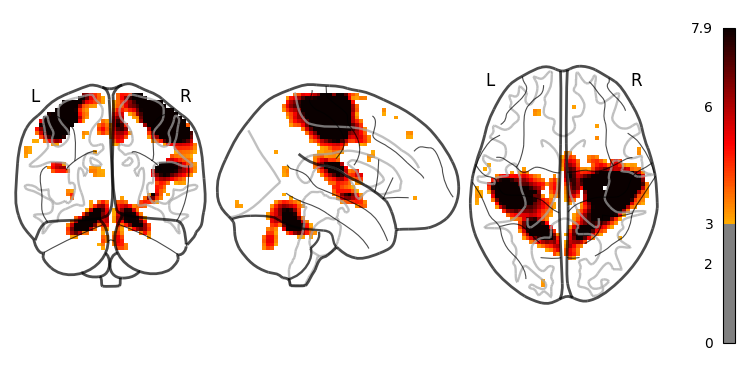

In [2]:
from nilearn import plotting

plotting.plot_glass_brain(stat_img, threshold=3)

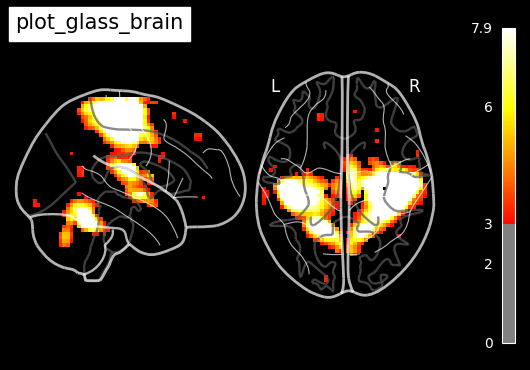

In [3]:
plotting.plot_glass_brain(
    stat_img,
    title="plot_glass_brain",
    black_bg=True,
    display_mode="xz",
    threshold=3,
)

Image Ready!

Image Shape: (2160, 3840, 3)


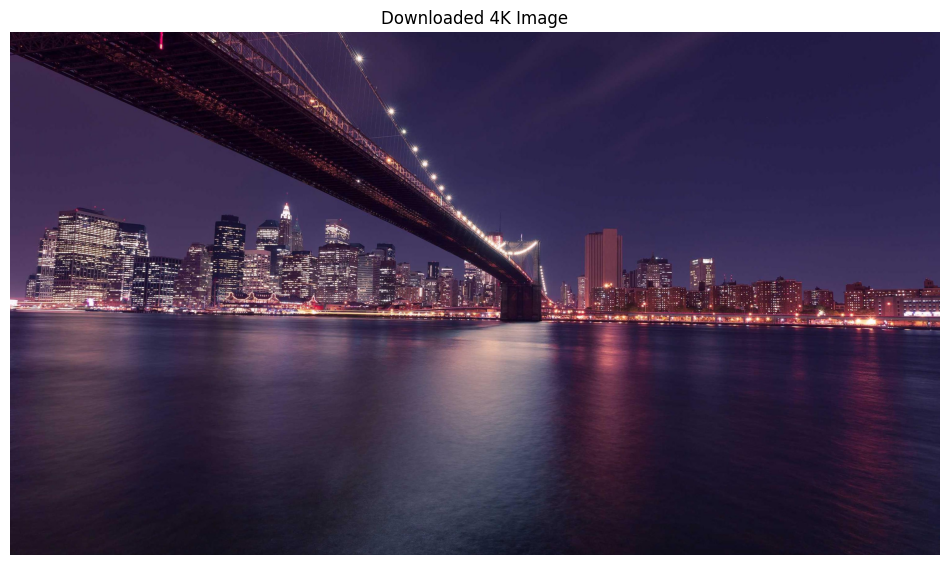


Input Tensor Shape: (1, 2160, 3840, 3)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 2158, 3838, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1079, 1919, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1077, 1917, 32) │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 538, 958, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 536, 956, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 268, 478, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 266, 476, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,346 (415.41 KB)

 Trainable params: 106,346 (415.41 KB)

 Non-trainable params: 0 (0.00 B)


Running CNN...


In [ ]:
import os
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense

# ==========================================================
# Step 1: Download a random 4K image
# ==========================================================

url = "https://picsum.photos/3840/2160"

if not os.path.exists("4k_image.jpg"):
    print("Downloading 4K image...")
    img_data = requests.get(url).content

    with open("4k_image.jpg", "wb") as f:
        f.write(img_data)

print("Image Ready!")

# ==========================================================
# Step 2: Load Image
# ==========================================================

image = cv2.imread("4k_image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("\nImage Shape:", image.shape)

plt.figure(figsize=(12,7))
plt.imshow(image)
plt.title("Downloaded 4K Image")
plt.axis("off")
plt.show()

# ==========================================================
# Step 3: Normalize
# ==========================================================

x = image.astype(np.float32) / 255.0
x = np.expand_dims(x, axis=0)

print("\nInput Tensor Shape:", x.shape)

# ==========================================================
# Step 4: CNN Model
# ==========================================================

model = Sequential([

    Conv2D(16, (3,3), activation="relu",
           input_shape=(2160,3840,3)),

    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu"),

    GlobalAveragePooling2D(),

    Dense(64, activation="relu"),

    Dense(10, activation="softmax")

])

model.summary()

# ==========================================================
# Step 5: Prediction
# ==========================================================

print("\nRunning CNN...")

prediction = model.predict(x)

print("\nPrediction Shape:", prediction.shape)
print("\nPrediction Vector:\n")
print(prediction)

print("\nPredicted Class:", np.argmax(prediction))

# ==========================================================
# Step 6: Display Feature Maps
# ==========================================================

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[0].output
)

feature_maps = feature_model.predict(x)

print("\nFeature Map Shape:", feature_maps.shape)

# Display first 16 feature maps
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Filter {i+1}")

plt.tight_layout()
plt.show()